1.import Required Libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

2.Load the Dataset

In [5]:
df = pd.read_csv('whatsapp_reviews.csv')
df.head()

,review_id,rating,review_text,review_date,helpful
0,56887e3c-1684-4ced-834e-befc7a66fc7d,5,Great 👍,11/26/2025 22:08,0
1,0da4488e-7158-4ea6-bcb9-17b9b3867642,1,plz whats up unban,11/26/2025 22:08,0
2,5a20e8e3-9e00-4360-a539-16953e309a3a,1,my contact didn't show on WhatsApp .. for priv...,11/26/2025 22:06,0
3,0cf26263-1c10-473e-ae15-d6390884fef7,1,Can you guys let archived group chats stay arc...,11/26/2025 22:05,1
4,54eebd96-041e-4baf-a8f1-adf603658c28,5,it is the g.o.a.t🇿🇼,11/26/2025 22:04,0


3.Explore Dataset Information

In [6]:
df.tail()


,review_id,rating,review_text,review_date,helpful
5395,8caf4de7-d4f7-4807-aeb8-feb23813348c,5,it's really excellent app,11/21/2025 19:57,0
5396,5b50a06d-cdd1-49eb-9ad2-e67ce747de96,5,it's very secret options all is clear but they...,11/21/2025 19:56,0
5397,d0d951c4-8948-4f35-826a-6f3d7e4e52fd,5,best app in the world 🌍🌎,11/21/2025 19:55,0
5398,cfe66013-059d-4750-820d-f3d9bda783fb,5,the best,11/21/2025 19:55,0
5399,2371d0ea-d934-44bf-98ee-75febe995c4a,5,open the whatsapp,11/21/2025 19:54,0


In [7]:
df.columns

Index(['review_id', 'rating', 'review_text', 'review_date', 'helpful'], dtype='str')

In [8]:
# rows and columns
df.shape

(5400, 5)

In [9]:
# data types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   review_id    5400 non-null   str  
 1   rating       5400 non-null   int64
 2   review_text  5400 non-null   str  
 3   review_date  5400 non-null   str  
 4   helpful      5400 non-null   int64
dtypes: int64(2), str(3)
memory usage: 211.1 KB


4.check Missing Values

In [10]:
# check missing values

df.isnull().sum()

review_id      0
rating         0
review_text    0
review_date    0
helpful        0
dtype: int64

5.Data visualization

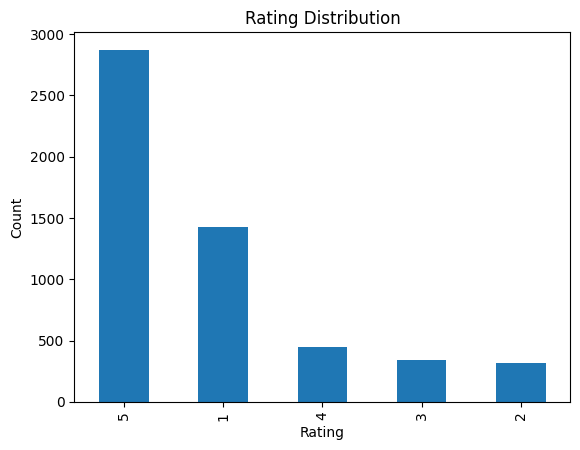

In [11]:
df['rating'].value_counts().plot(kind='bar')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

6.Sentiment Label creation

In [12]:
# Keep only positive & negative reviews
df = df[df['rating'] != 3]

# Create sentiment column
df['sentiment'] = df['rating'].apply(lambda x: 1 if x >= 4 else 0)

df[['rating', 'sentiment']].head()

,rating,sentiment
0,5,1
1,1,0
2,1,0
3,1,0
4,5,1


7.Define input and output variables

In [13]:
X = df['review_text']   # input text
y = df['sentiment']     # output label

8.Split Dataset inti Training and Testing Data

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

9.TF-IDF Vectorization

In [15]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

10.Train Lodistic Regression Model

In [16]:
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

11.Make Predictions

In [17]:
y_pred = model.predict(X_test_tfidf)

12.Evaluate Model Accuracy

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.8033596837944664


In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[213 134]
 [ 65 600]]


13.Classification Report

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.61      0.68       347
           1       0.82      0.90      0.86       665

    accuracy                           0.80      1012
   macro avg       0.79      0.76      0.77      1012
weighted avg       0.80      0.80      0.80      1012



14.conclusion

In [22]:
print("The NLP-based sentiment analysis model was successfully implemented using TF-IDF vectorization and Logistic Regression. The model achieved good accuracy in classifying WhatsApp reviews into positive and negative sentiments.")

The NLP-based sentiment analysis model was successfully implemented using TF-IDF vectorization and Logistic Regression. The model achieved good accuracy in classifying WhatsApp reviews into positive and negative sentiments.
